# Auto Viz

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../../data_resources/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
import matplotlib.pyplot as plt

print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Shape of your Data Set loaded: (303, 14)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    13 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
Since Number of Rows in data 303 exceeds maximum, randomly sampling 303 rows for EDA...

################ Binary_Classification problem #####################
There are 1 duplicate rows in your dataset
    Alert: Dropping duplicate rows can sometimes cause your column data types to change to object!
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
age,int64,0.000000,13,29.000000,77.000000,No issue
sex,int64,0.000000,0,0.000000,1.000000,No issue
cp,int64,0.000000,1,0.000000,3.000000,No issue
trestbps,int64,0.000000,16,94.000000,200.000000,Column has 9 outliers greater than upper bound (170.00) or lower than lower bound(90.00). Cap them or remove them.
chol,int64,0.000000,50,126.000000,564.000000,Column has 5 outliers greater than upper bound (370.38) or lower than lower bound(115.38). Cap them or remove them.
fbs,int64,0.000000,0,0.000000,1.000000,No issue
restecg,int64,0.000000,0,0.000000,2.000000,No issue
thalach,int64,0.000000,30,71.000000,202.000000,Column has 1 outliers greater than upper bound (215.12) or lower than lower bound(84.12). Cap them or remove them.
exang,int64,0.000000,0,0.000000,1.000000,No issue
oldpeak,float64,0.000000,NA,0.000000,6.200000,Column has 5 outliers greater than upper bound (4.00) or lower than lower bound(-2.40). Cap them or remove them.


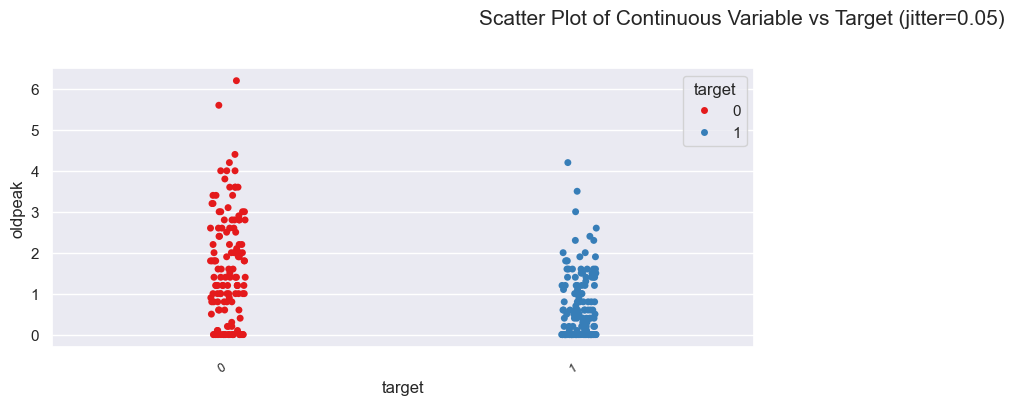

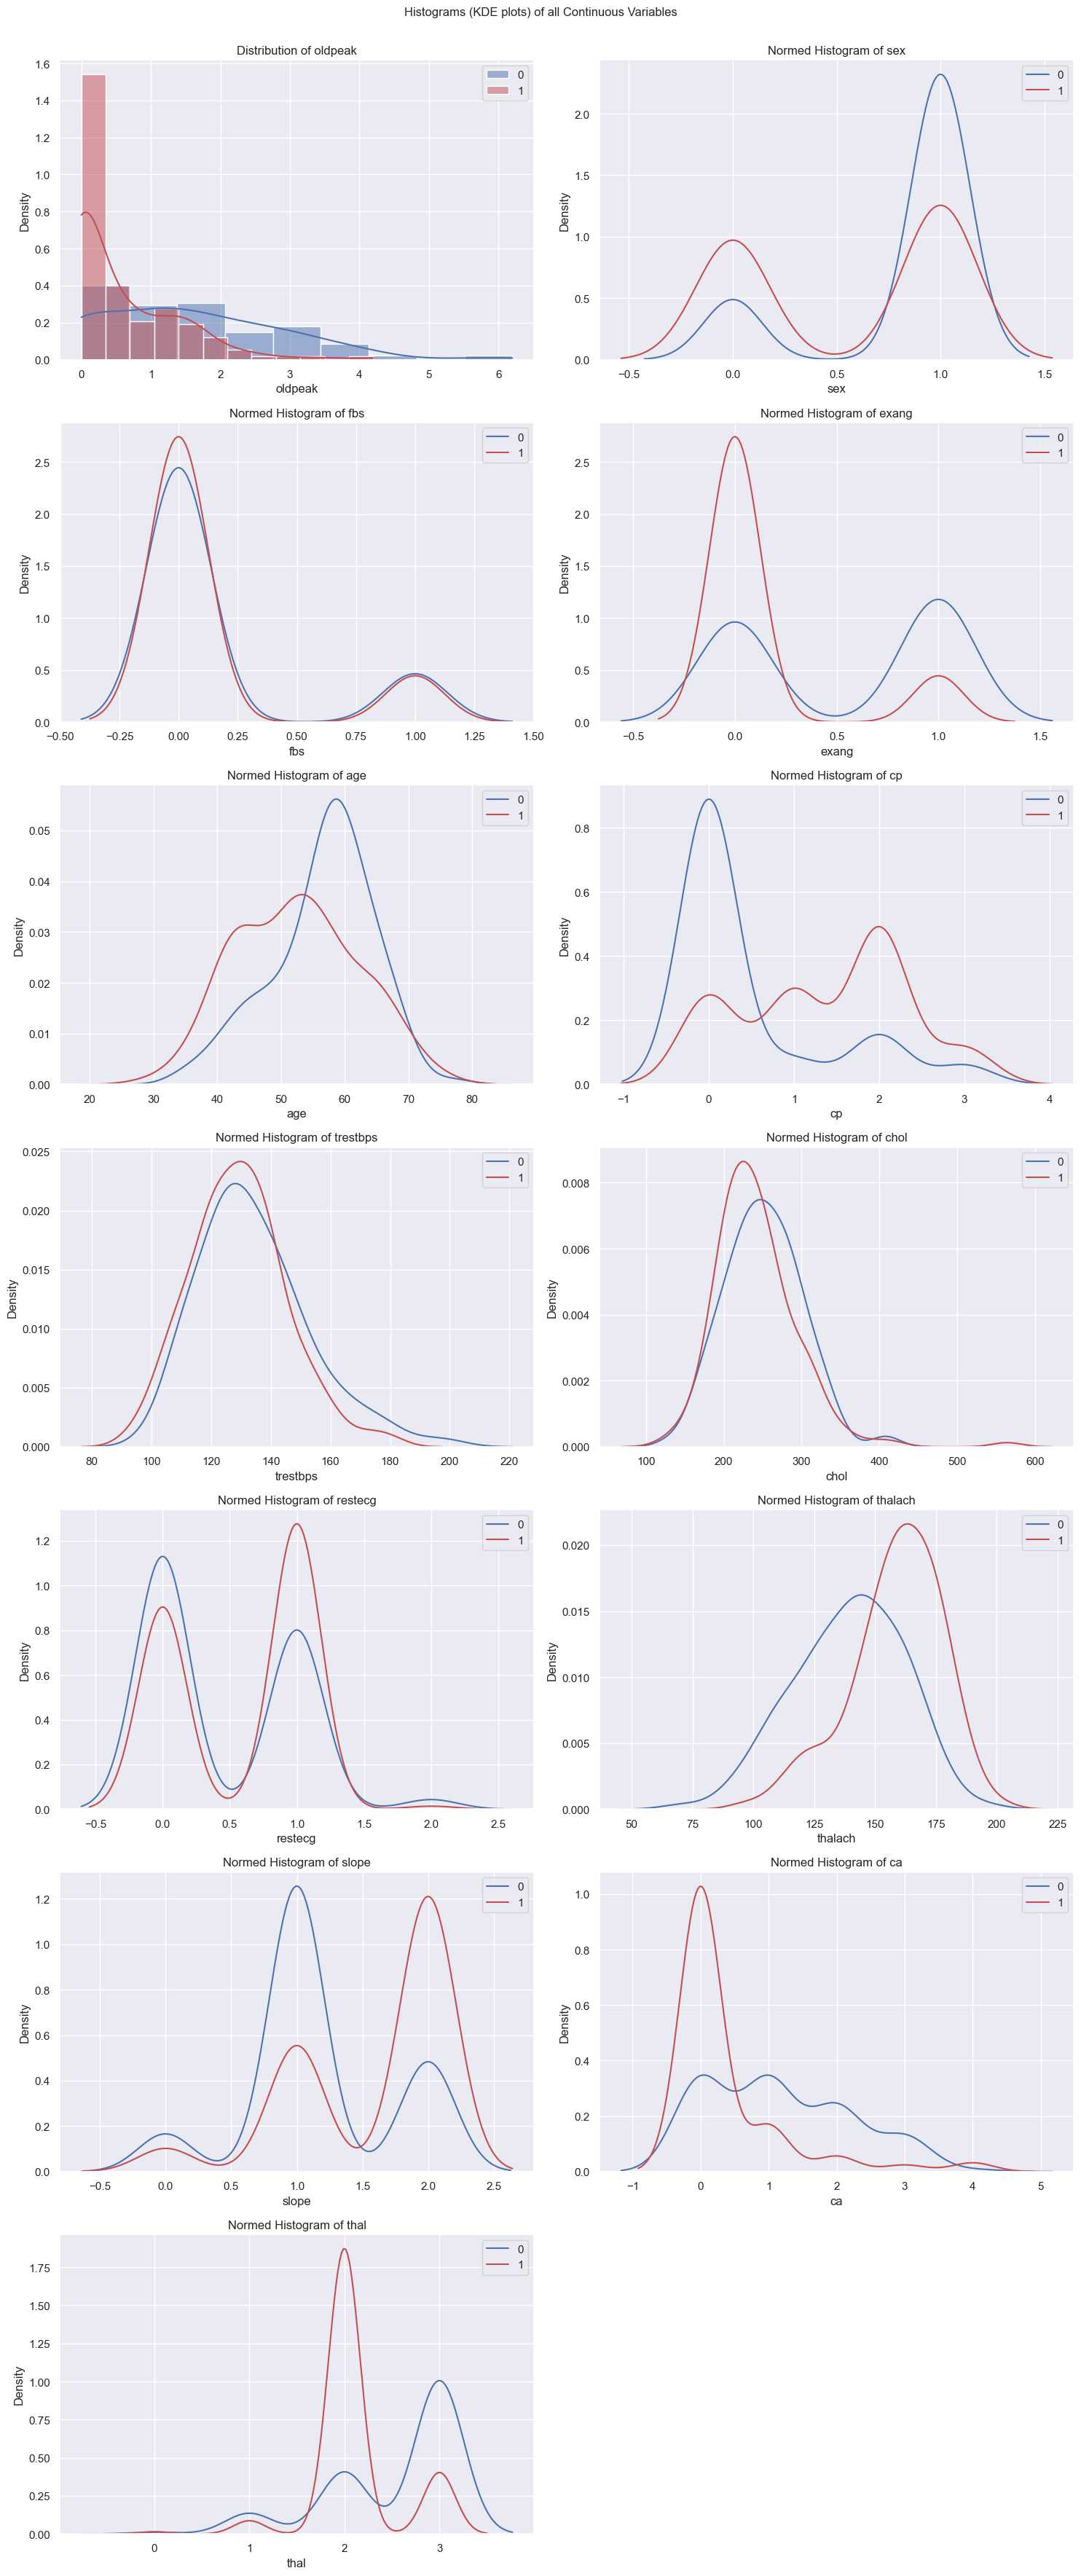

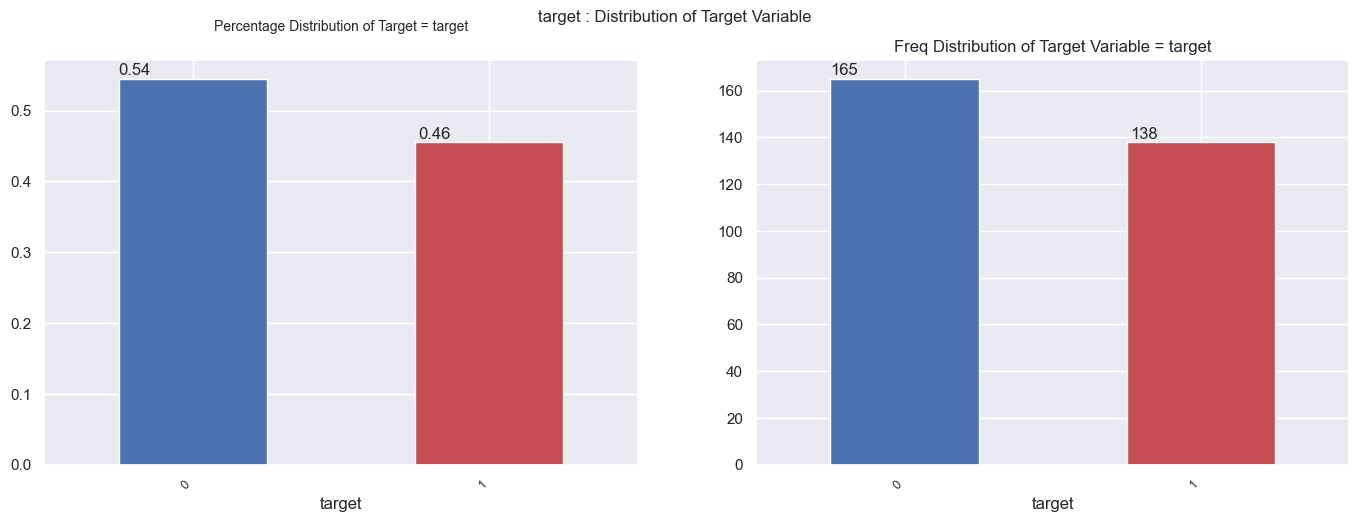

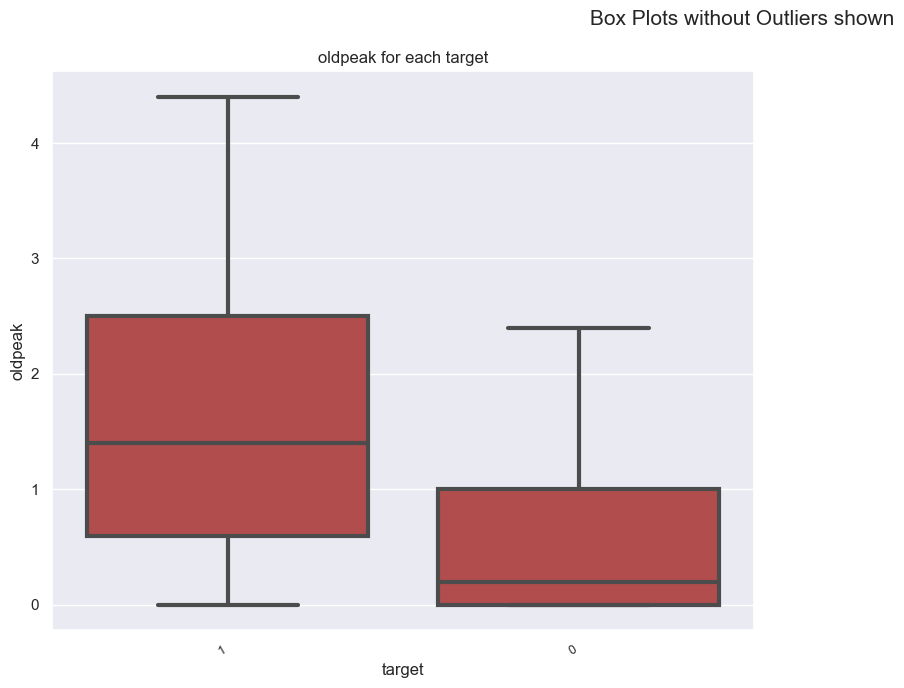

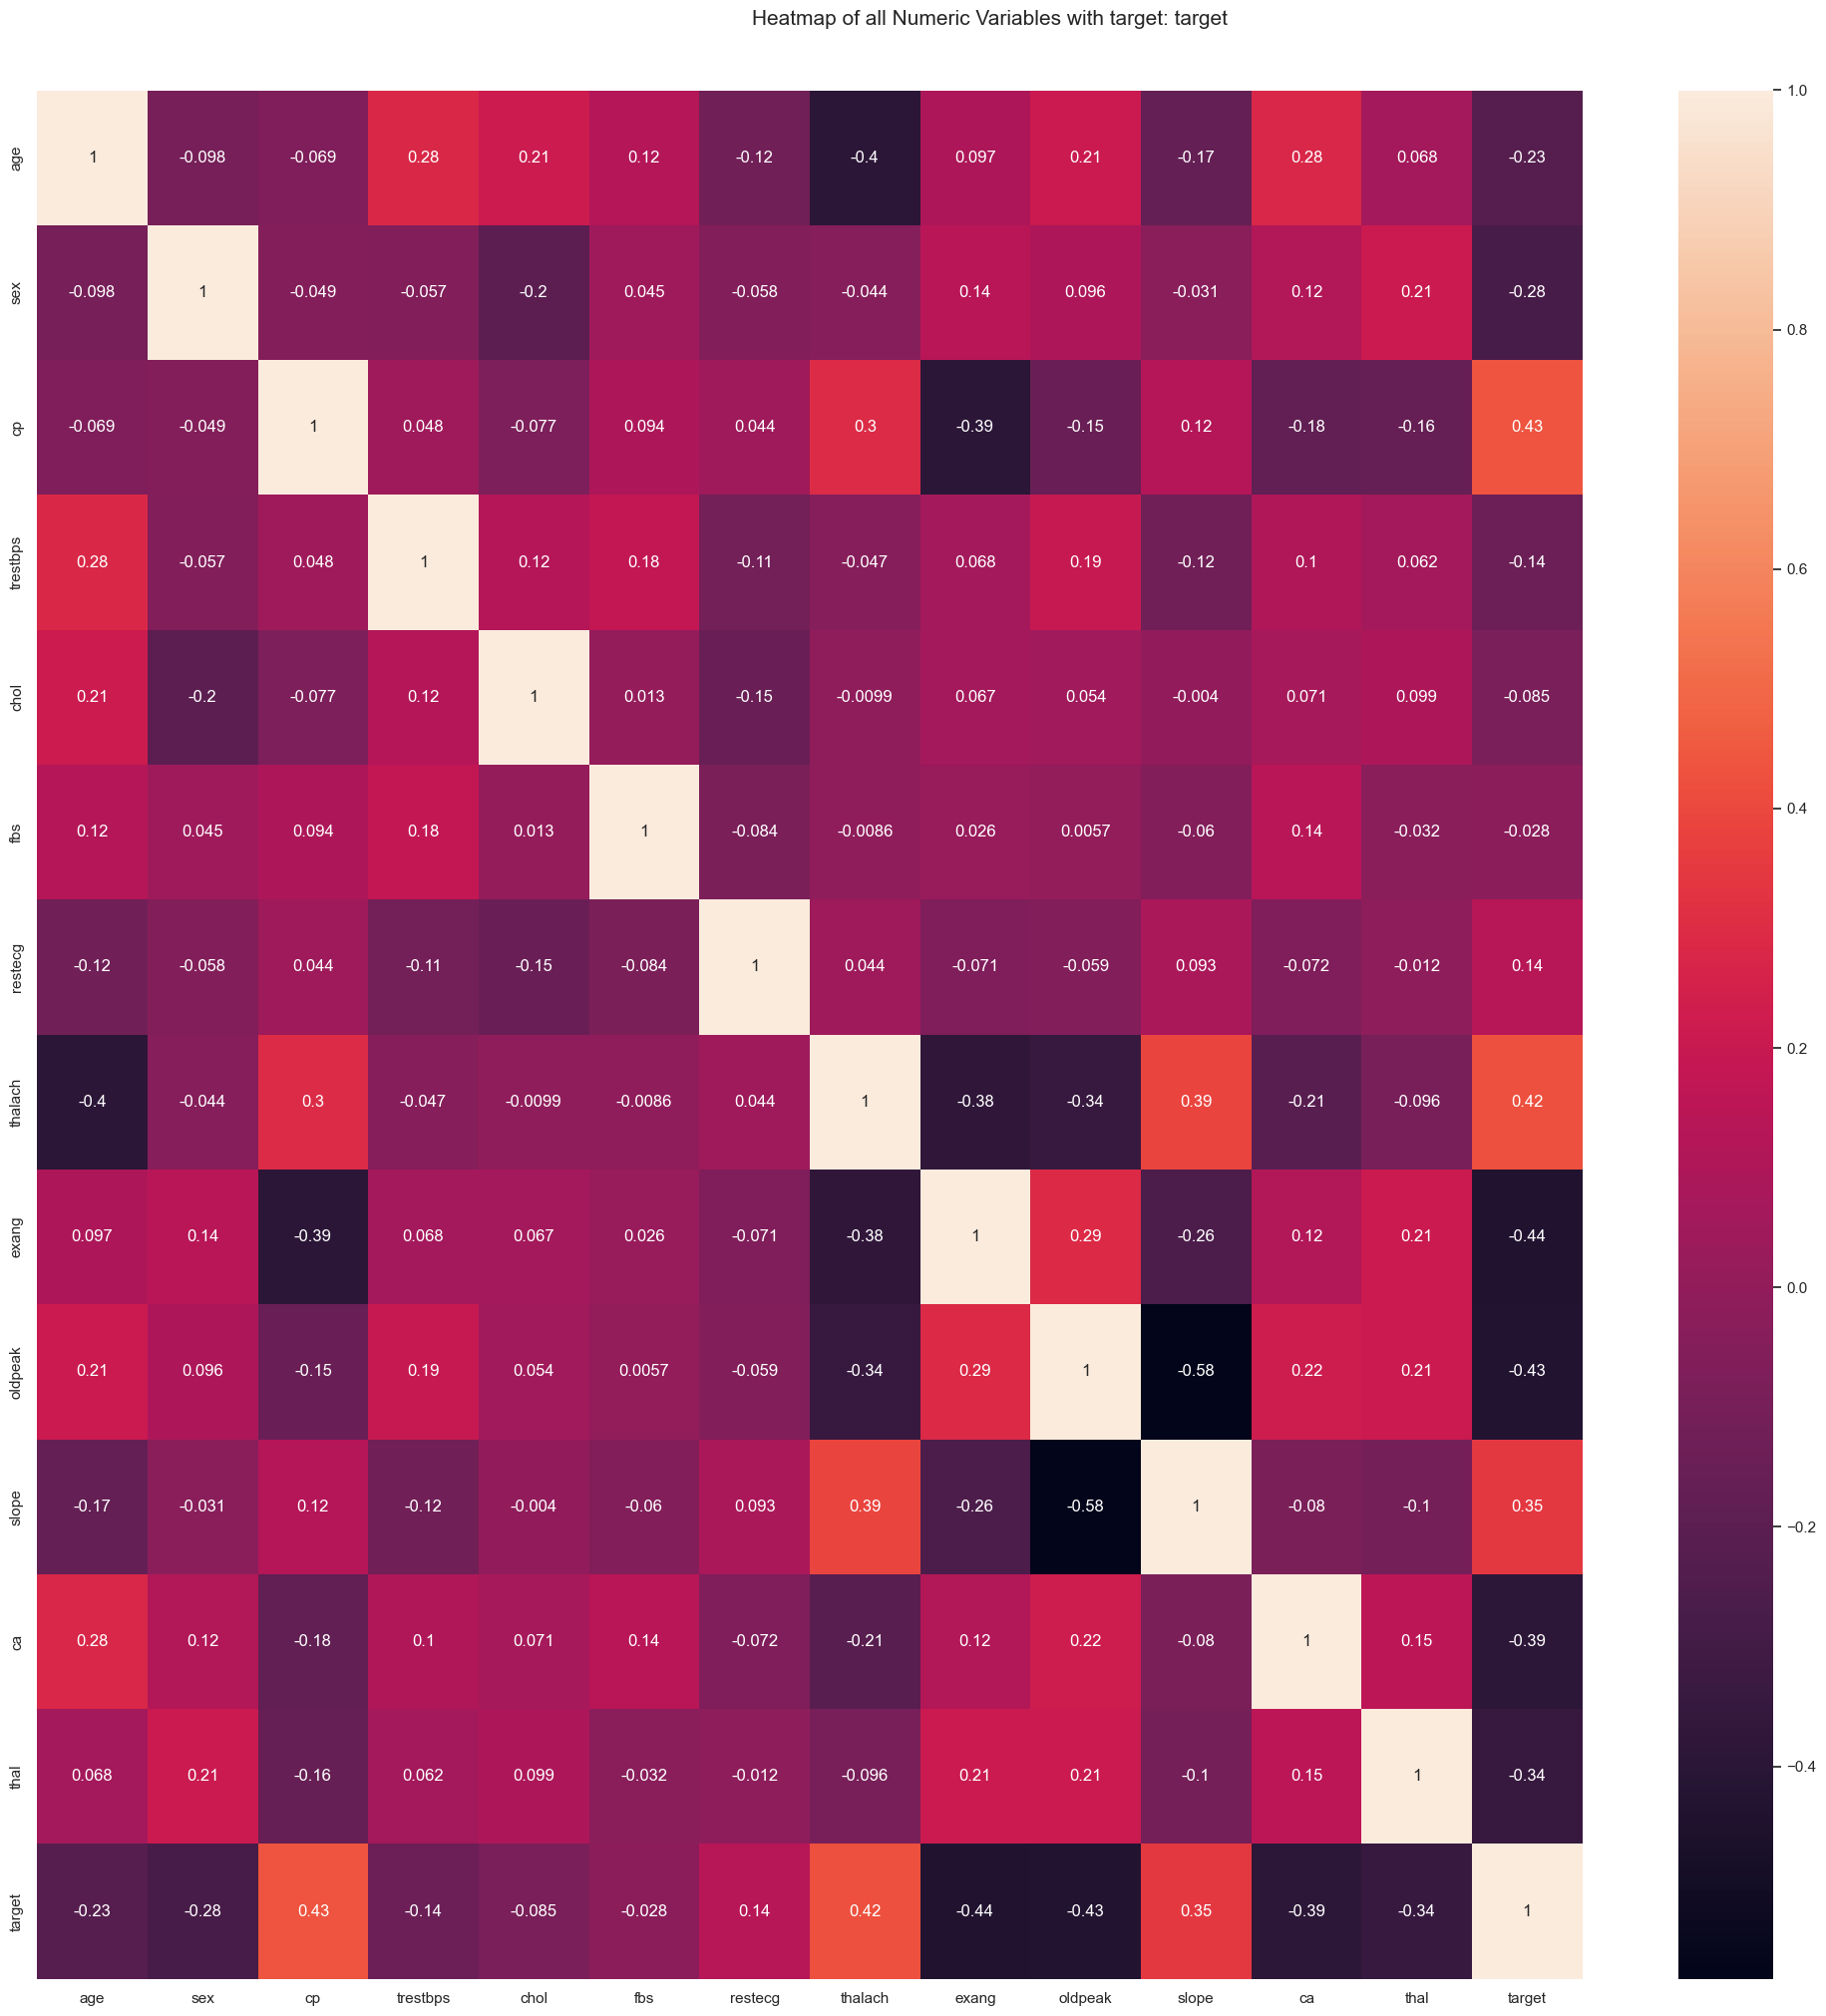

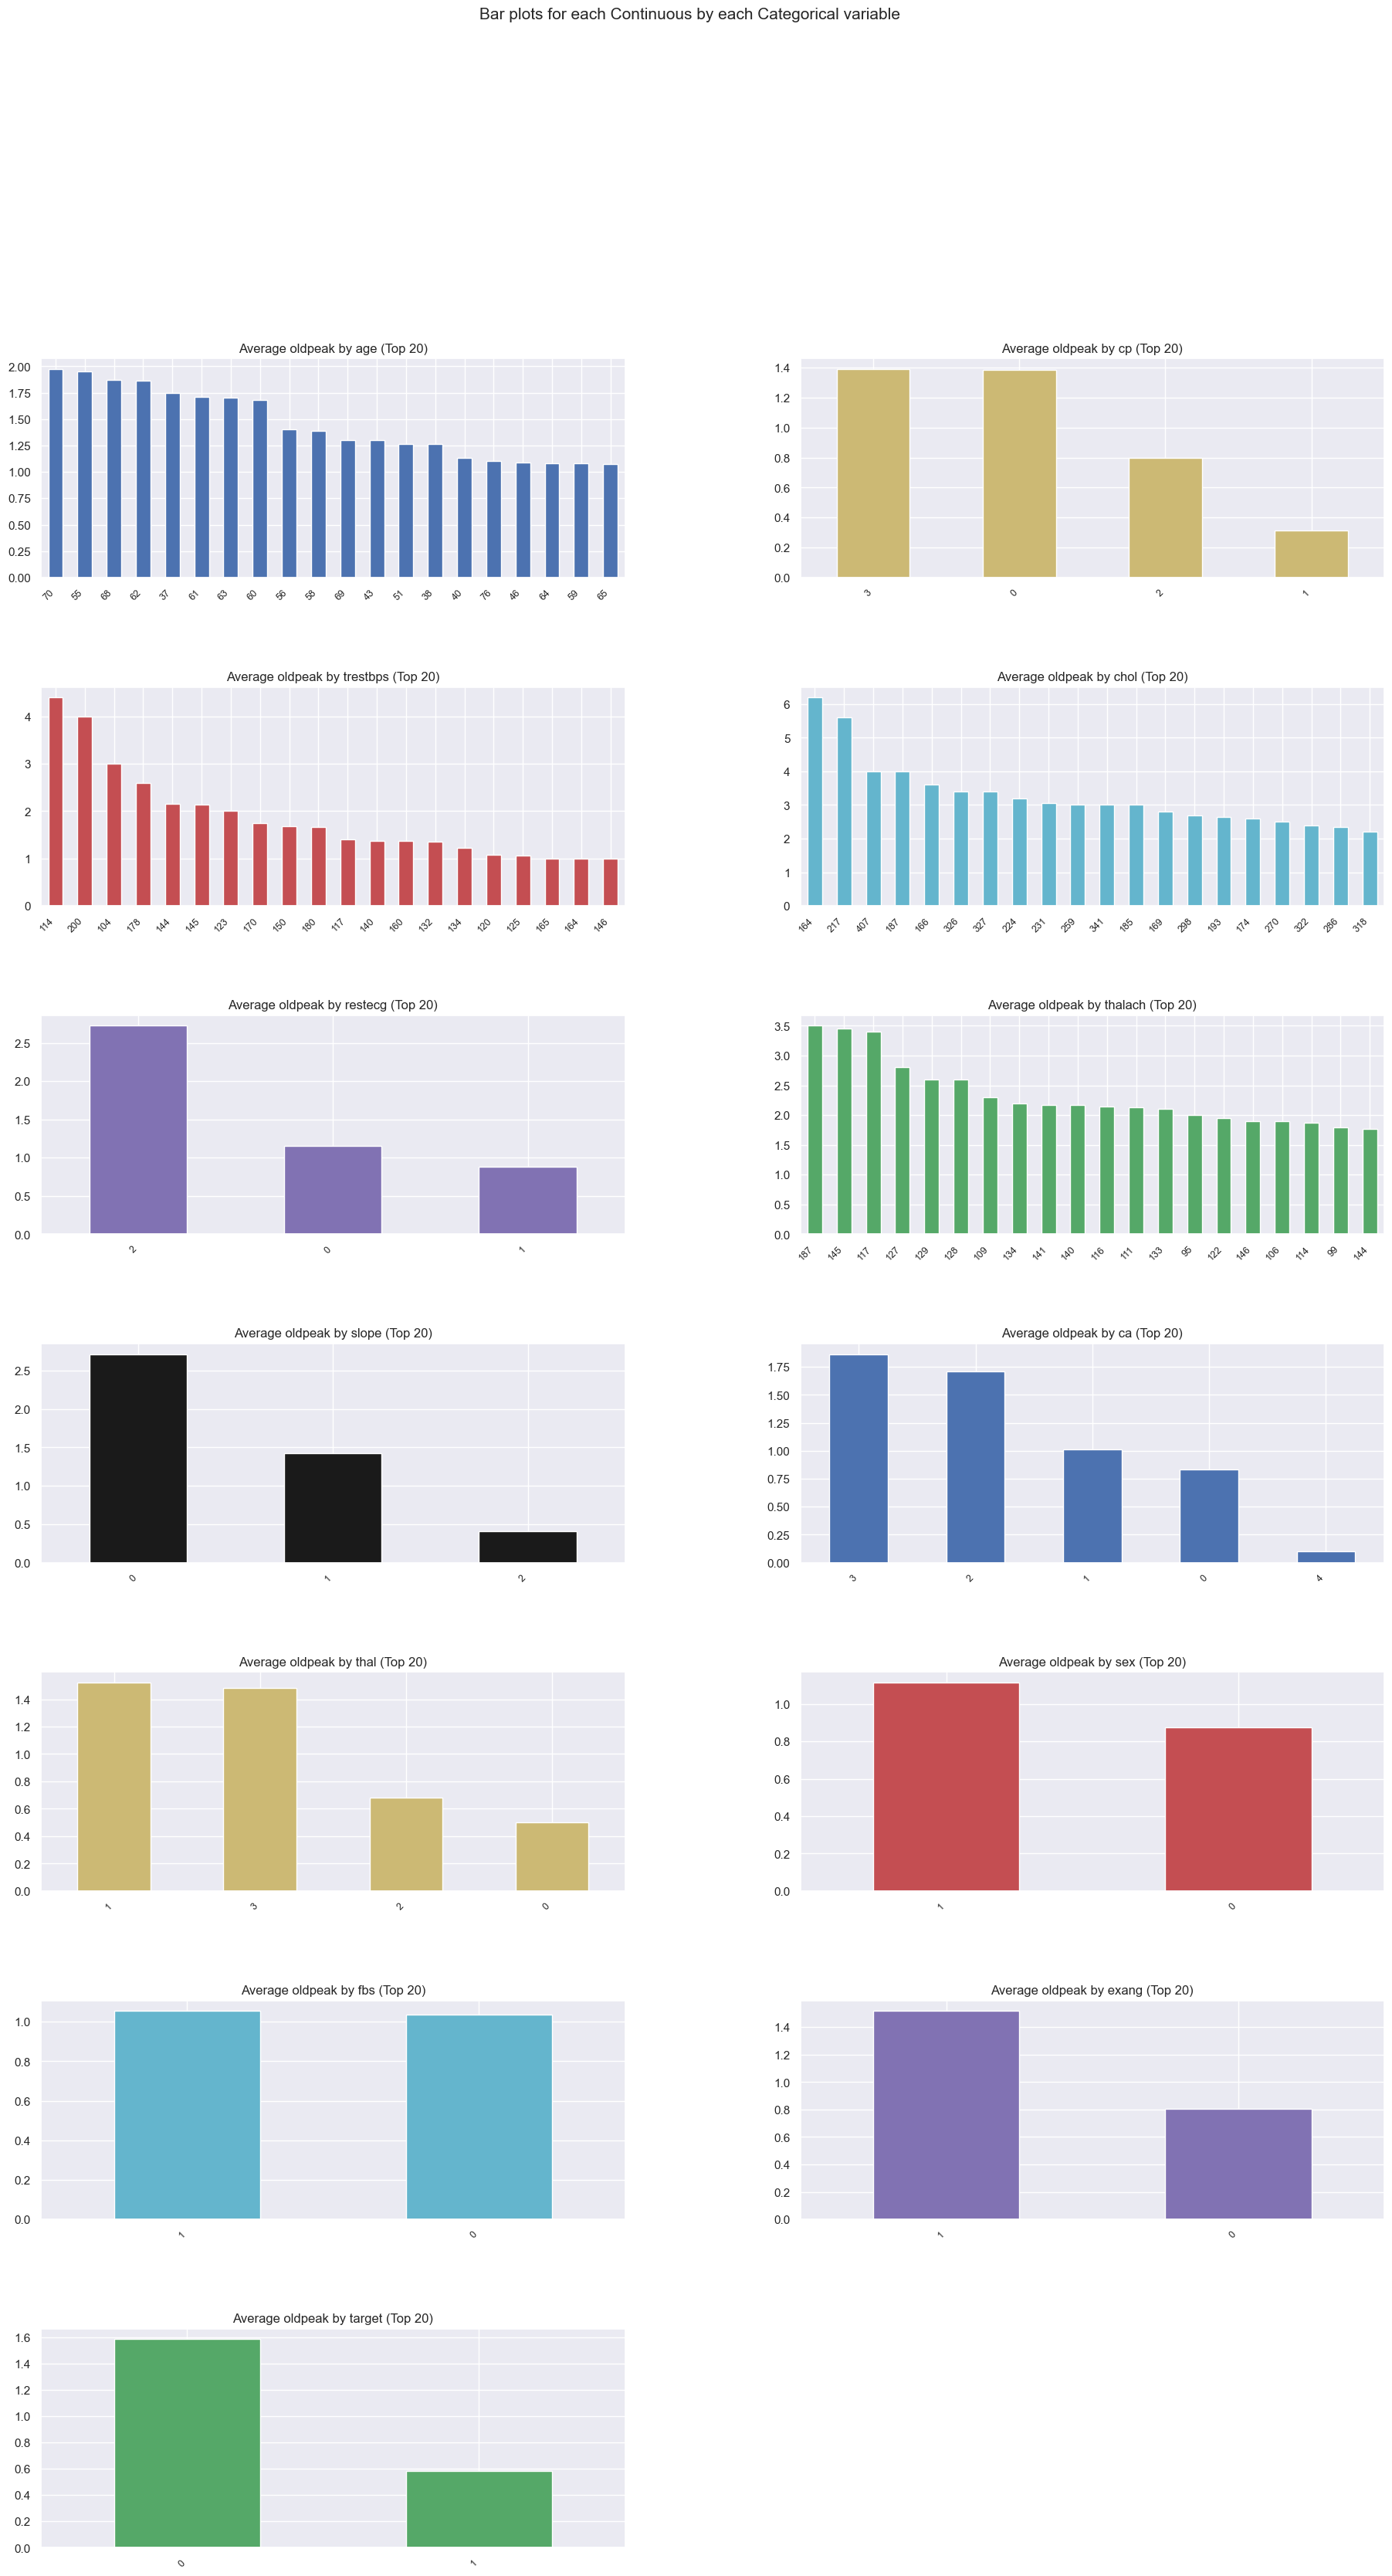

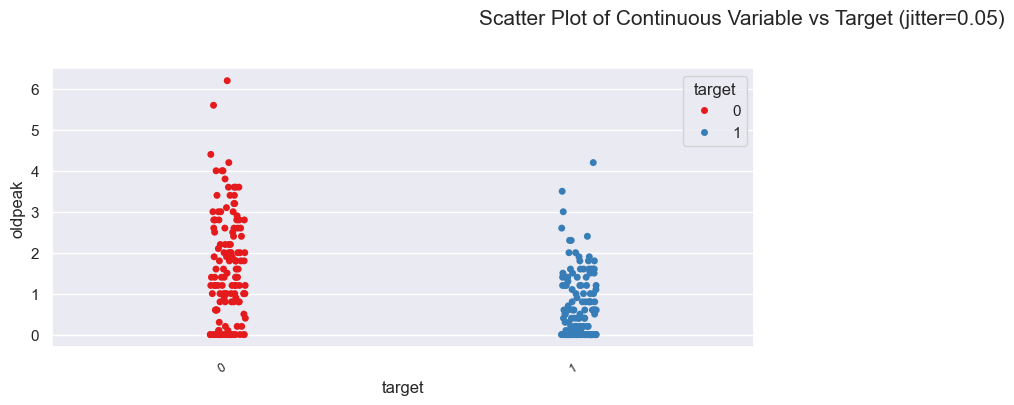

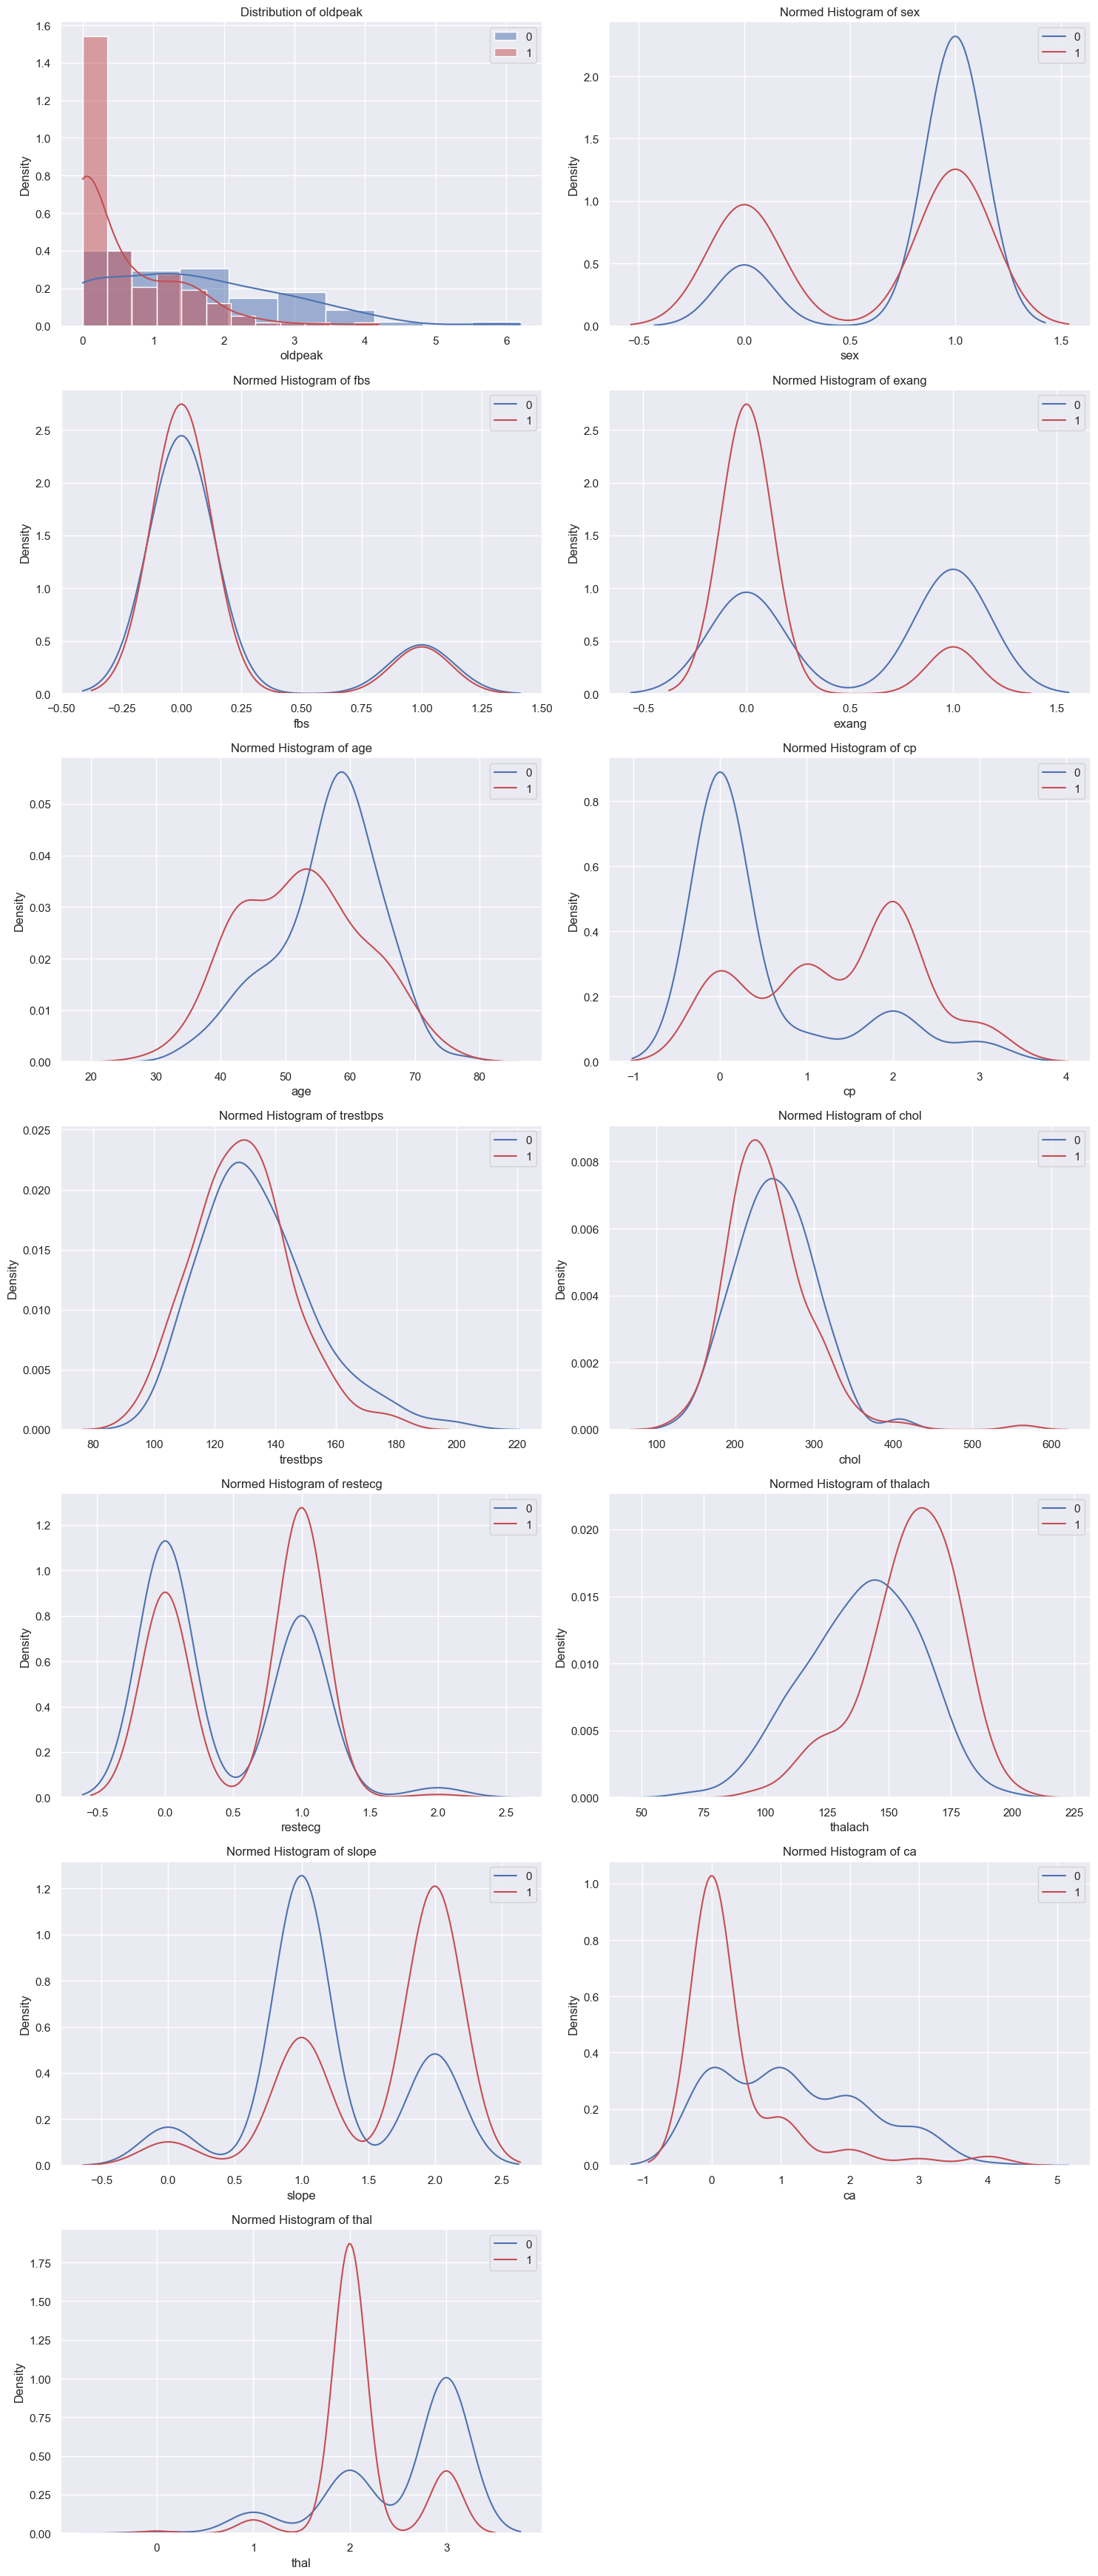

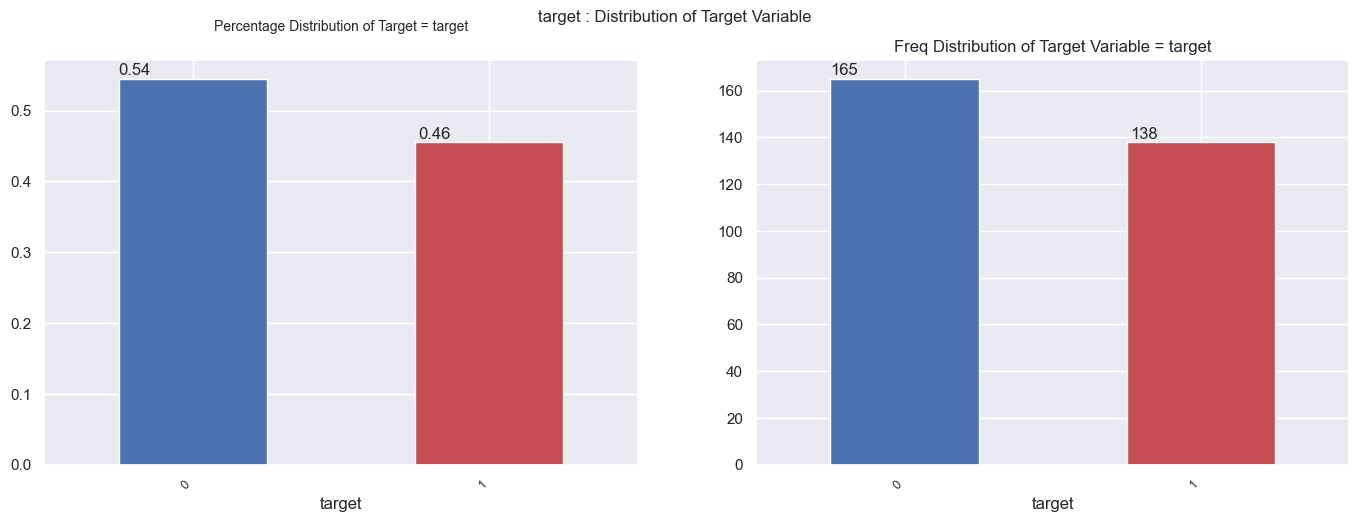

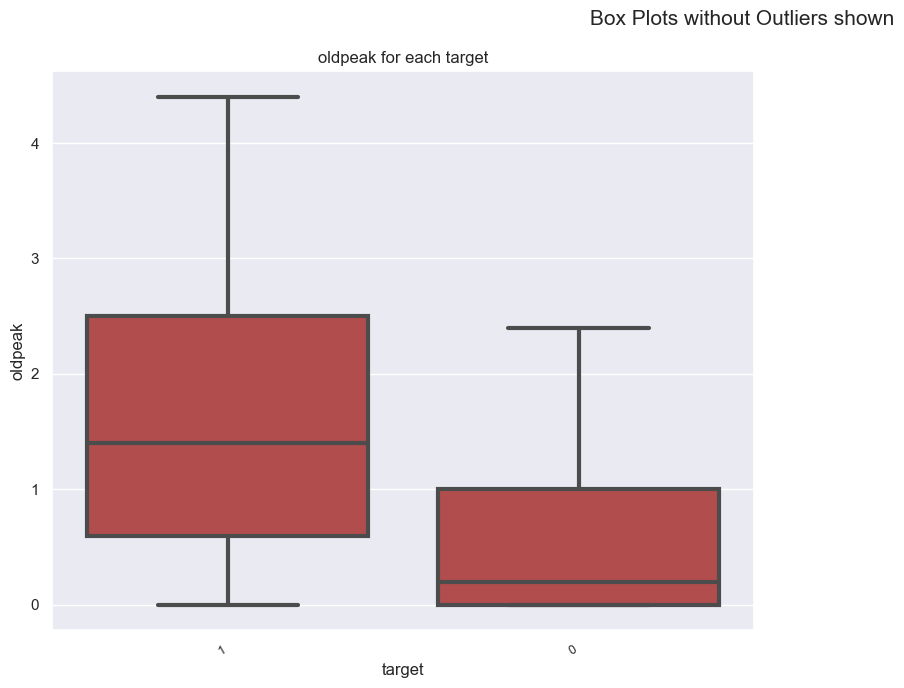

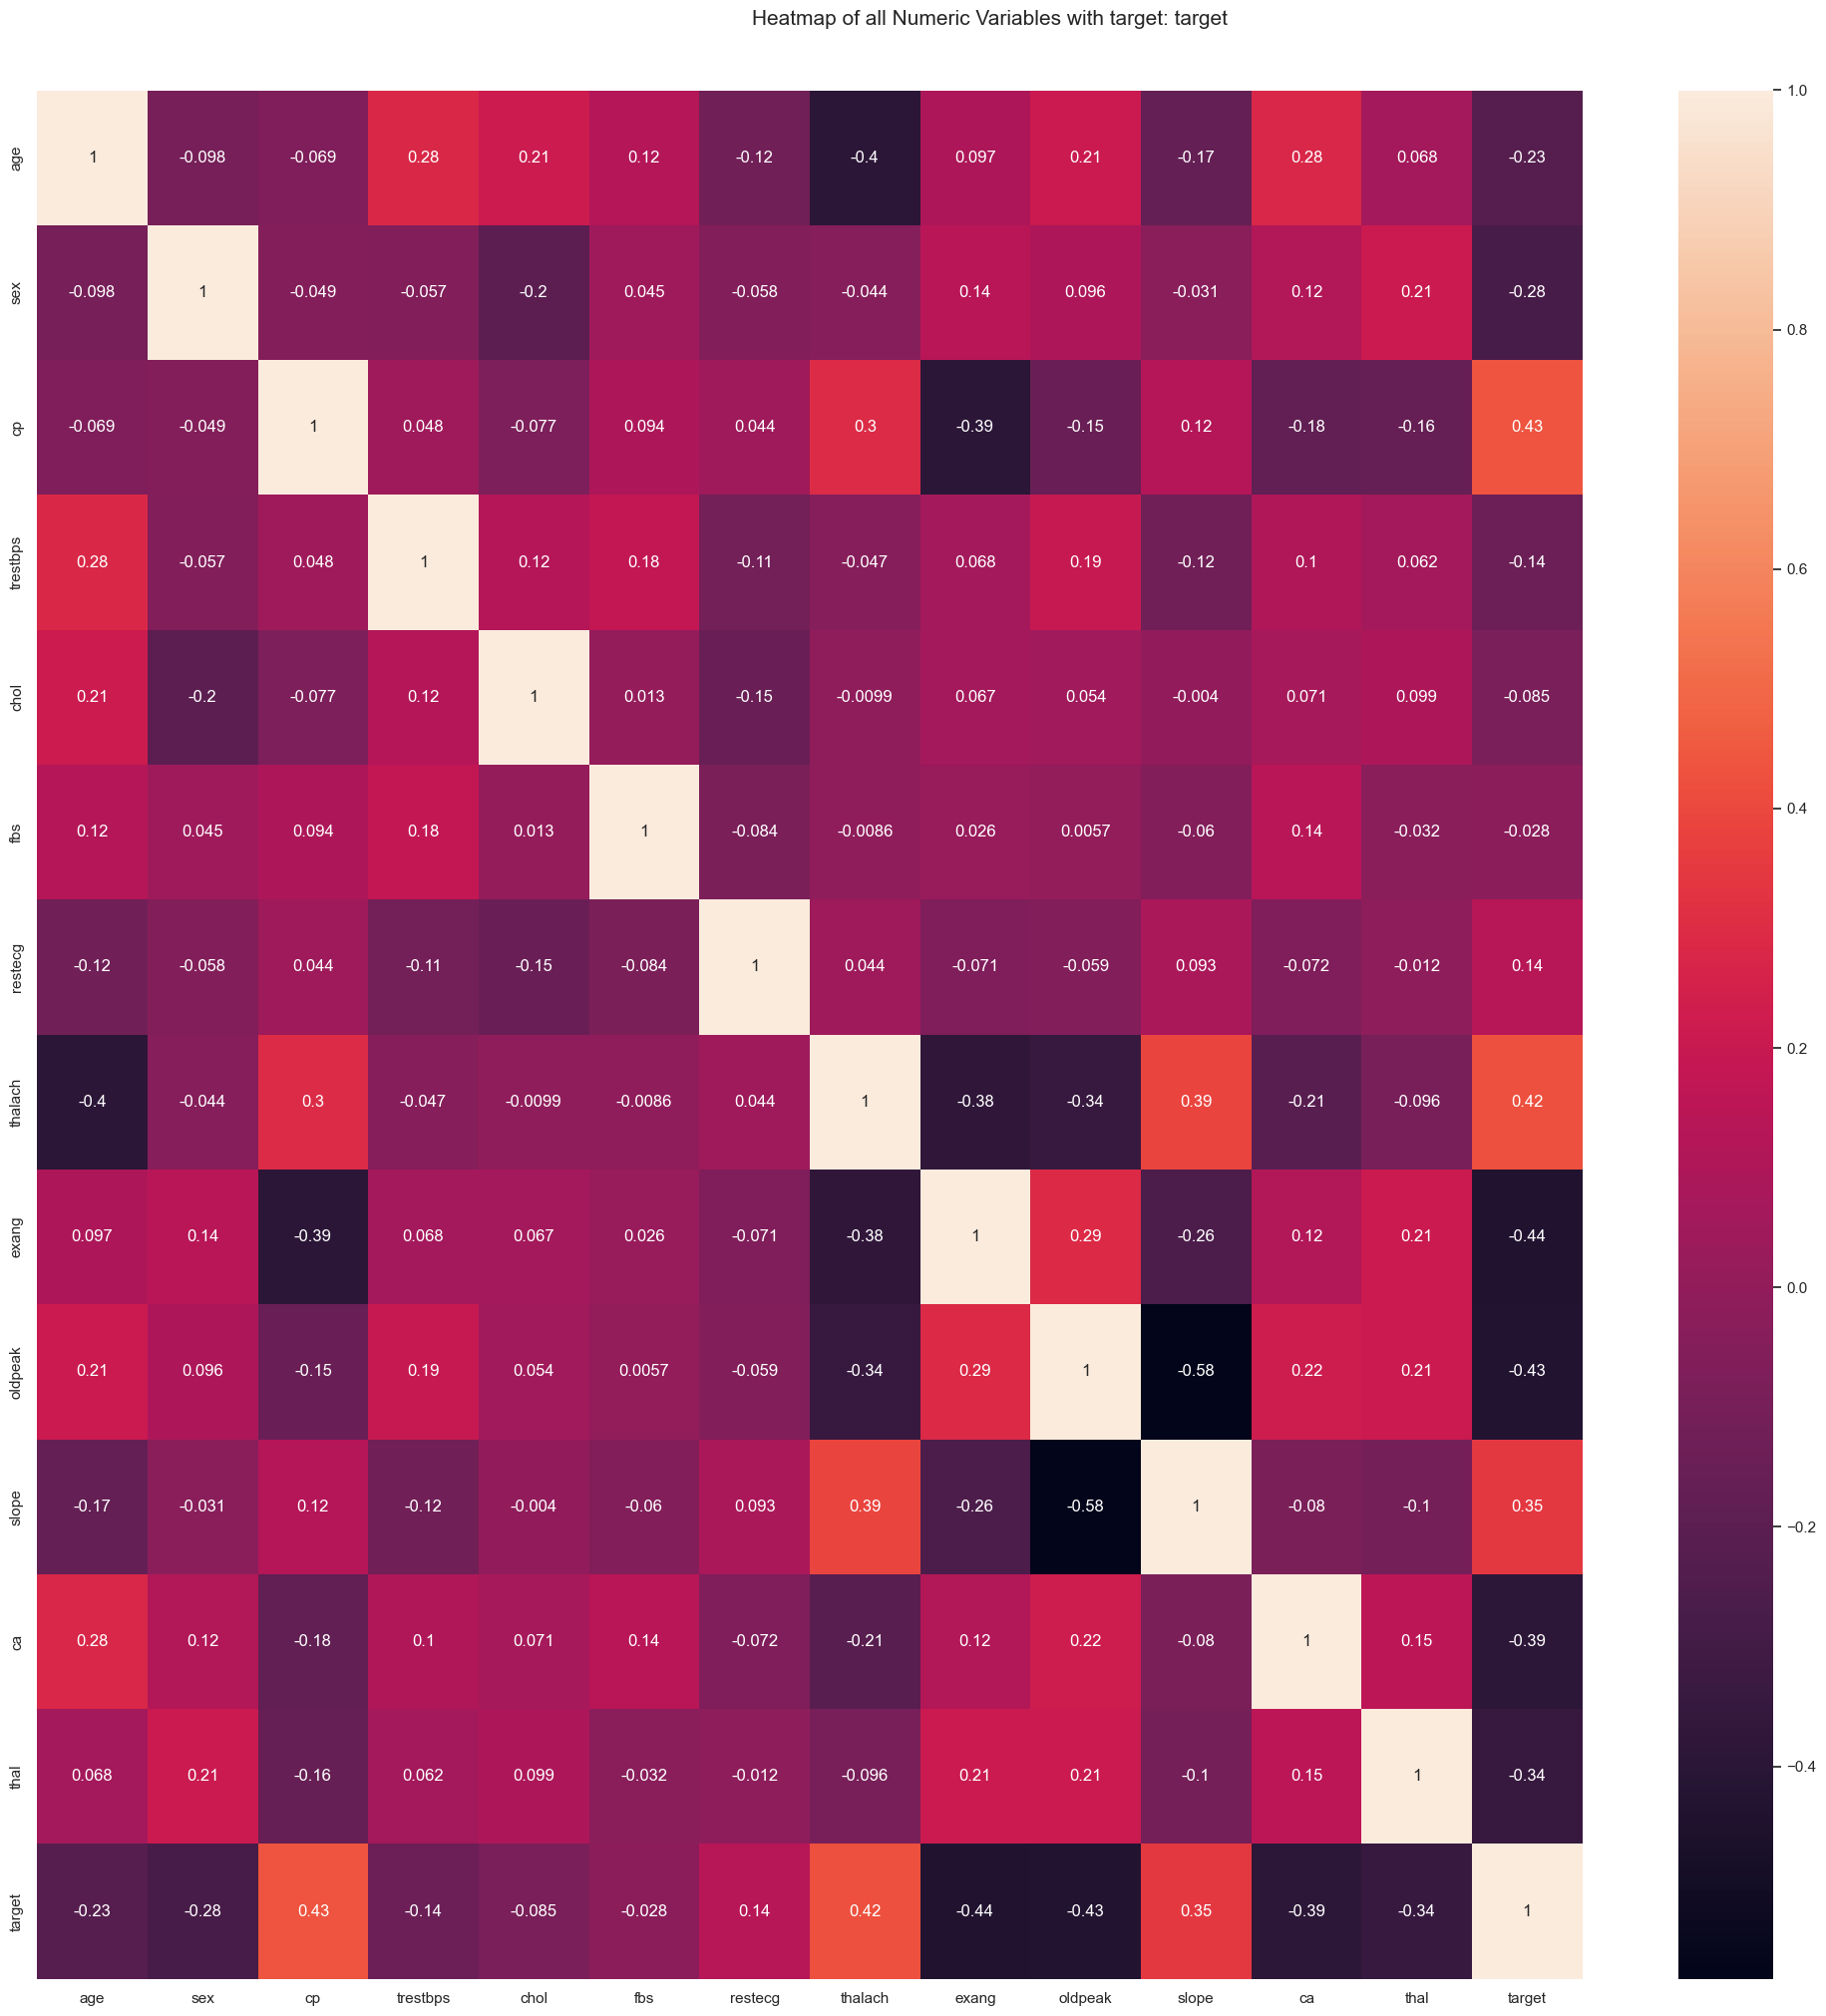

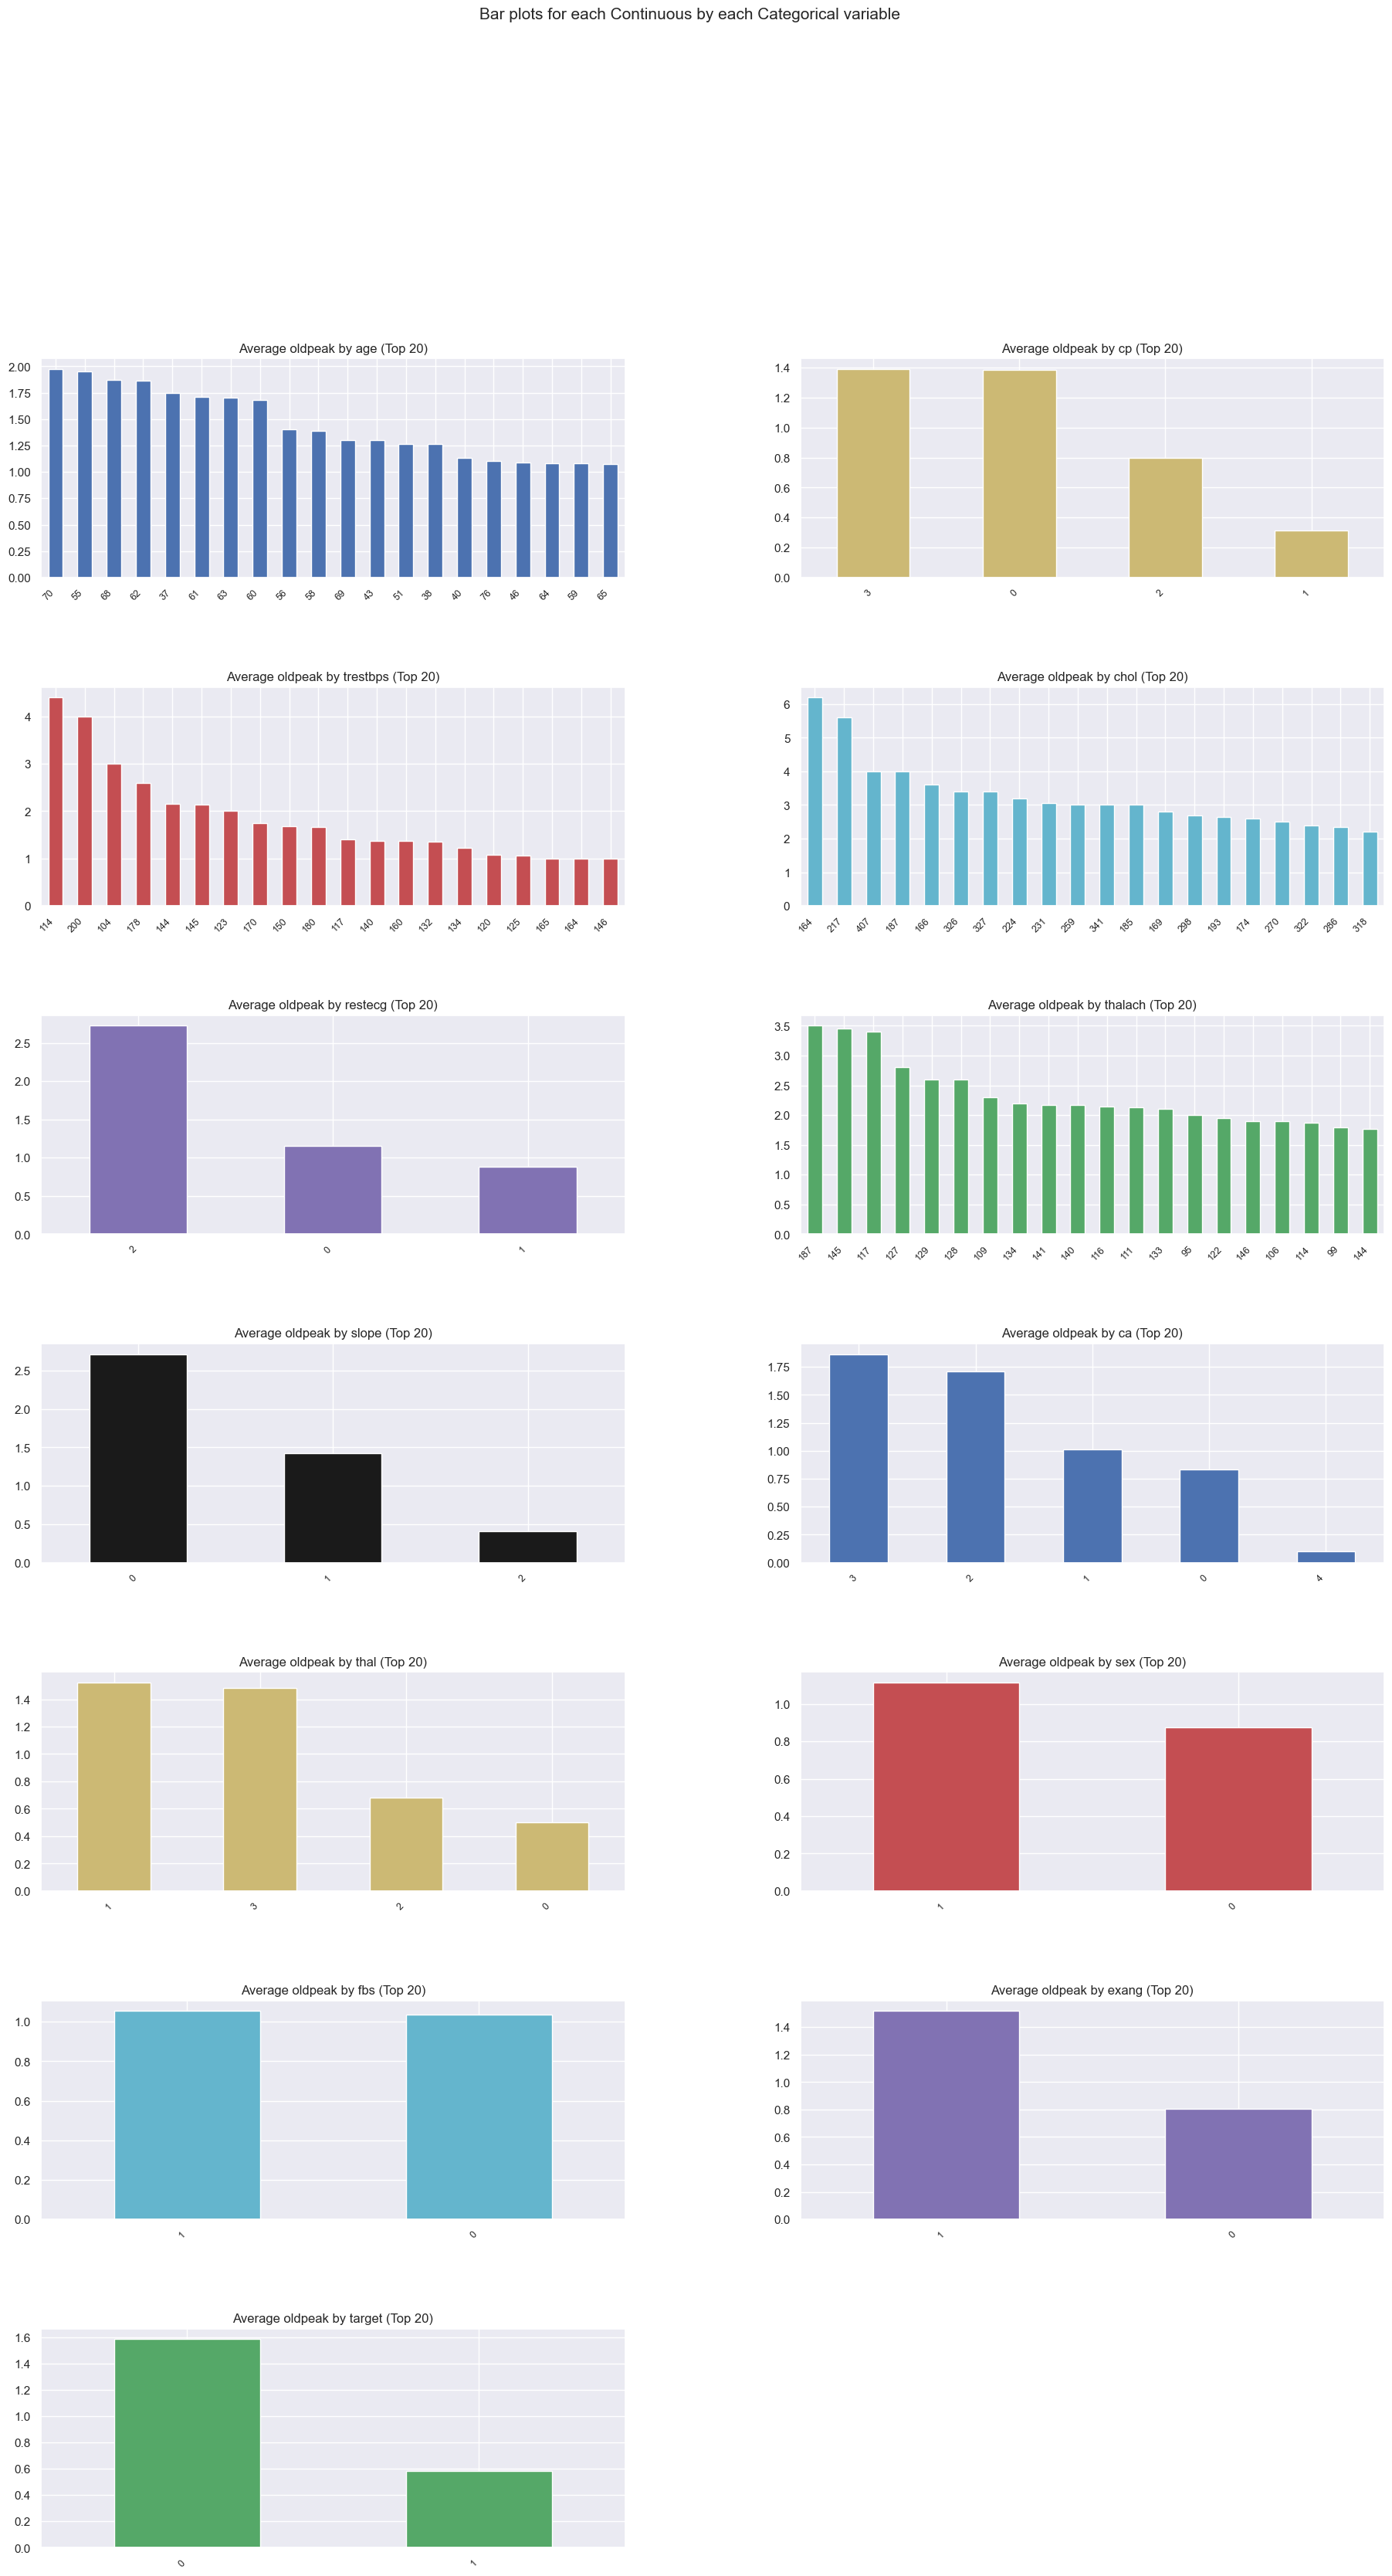

All Plots done
Time to run AutoViz = 18 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
225,70,1,0,145,174,0,1,125,1,2.60,0,0,3,0
152,64,1,3,170,227,0,0,155,0,0.60,1,0,3,1
228,59,1,3,170,288,0,0,159,0,0.20,1,0,3,0
201,60,1,0,125,258,0,0,141,1,2.80,1,1,3,0
52,62,1,2,130,231,0,1,146,0,1.80,1,3,3,1
245,48,1,0,124,274,0,0,166,0,0.50,1,0,3,0
175,40,1,0,110,167,0,0,114,1,2.00,1,0,3,0
168,63,1,0,130,254,0,0,147,0,1.40,1,1,3,0
223,56,0,0,200,288,1,0,133,1,4.00,0,2,3,0
217,63,1,0,130,330,1,0,132,1,1.80,2,3,3,0


In [9]:
%matplotlib inline
from autoviz.AutoViz_Class import AutoViz_Class
import matplotlib.pyplot as plt
import seaborn as sns
av = AutoViz_Class()

av.AutoViz(filename='',
           dfte=df,
           depVar='target',
           verbose=0,
           max_rows_analyzed=df.shape[0],
           max_cols_analyzed=df.shape[1]
           )


# Auto ML 실습

In [6]:
from sklearn.model_selection import train_test_split
x = df.drop('target', axis=1)
y = df["target"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(242, 13) (242,)
(61, 13) (61,)


In [7]:
from lazypredict.Supervised import LazyClassifier

lcf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lcf.fit(x_train, x_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 132, number of negative: 110
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 249
[LightGBM] [Info] Number of data points in the train set: 242, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [8]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SGDClassifier,0.85,0.84,0.84,0.85,0.04
RandomForestClassifier,0.84,0.82,0.82,0.83,0.31
GaussianNB,0.82,0.81,0.81,0.82,0.04
ExtraTreesClassifier,0.82,0.81,0.81,0.82,0.18
SVC,0.82,0.81,0.81,0.82,0.04
BaggingClassifier,0.80,0.80,0.80,0.80,0.09
KNeighborsClassifier,0.80,0.79,0.79,0.80,0.04
LogisticRegression,0.80,0.79,0.79,0.80,0.04
BernoulliNB,0.80,0.79,0.79,0.80,0.04


# 옵튜나 실습

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import optuna
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
data

x_data = data.data
y_data = data.target

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [5]:
def objective(trial):
    model_type = trial.suggest_categorical("model", ["RandomForestRegressor", "GradientBoostingRegressor", "XGBRegressor"])

    if model_type == "RandomForestRegressor":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 50),
            min_samples_split=trial.suggest_int("min_samples_split", 2,10),
            random_state=42
        )
    elif model_type == "GradientBoostingRegressor":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            random_state=42
        )
    elif model_type == "XGBRegressor":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample = trial.suggest_float("subsamplt", 0.5, 1.0),
            random_state=42
        )
    
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return r2_score(y_test, y_pred)


opt = optuna.create_study(direction="maximize")

opt.optimize(
    objective, n_trials=10 # 여기 들어갈함수는 내가 선택한 모델을 학습시키는 코드와 파라미터 범위 세팅을 하는 함수
)

print("최고의 모델", opt.best_params["model"])
print("최고의 파라미터스", opt.best_params)
print("최고 스코어", opt.best_value)

[I 2025-08-08 15:51:04,387] A new study created in memory with name: no-name-fe99ef6f-a1b3-4f12-a5ff-c64f504a0729
[I 2025-08-08 15:51:19,599] Trial 0 finished with value: 0.6459785262662601 and parameters: {'model': 'GradientBoostingRegressor', 'n_estimators': 1174, 'max_depth': 42, 'learning_rate': 0.2153506484102579}. Best is trial 0 with value: 0.6459785262662601.
[I 2025-08-08 15:52:37,916] Trial 1 finished with value: 0.8069714653691429 and parameters: {'model': 'RandomForestRegressor', 'n_estimators': 692, 'max_depth': 21, 'min_samples_split': 6}. Best is trial 1 with value: 0.8069714653691429.
[I 2025-08-08 15:52:48,495] Trial 2 finished with value: 0.7953285089053919 and parameters: {'model': 'XGBRegressor', 'n_estimators': 541, 'max_depth': 34, 'learning_rate': 0.2571956581156983, 'subsamplt': 0.7046823672771172}. Best is trial 1 with value: 0.8069714653691429.
[I 2025-08-08 15:54:06,433] Trial 3 finished with value: 0.7227528563637218 and parameters: {'model': 'GradientBoosti

최고의 모델 XGBRegressor
최고의 파라미터스 {'model': 'XGBRegressor', 'n_estimators': 528, 'max_depth': 30, 'learning_rate': 0.09531849126483675, 'subsamplt': 0.5107343095285993}
최고 스코어 0.8180294170072513
